# Sprint 1 — Ground Truth Validation

Validates `data/test_history.db` loaded from RTPTorrent CSVs.

**Run from repo root** with the venv active:
```
.venv\Scripts\Activate.ps1
jupyter notebook notebooks/01_ground_truth_validation.ipynb
```

In [1]:
import os
import warnings
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy connectable.*")

# Resolve repo root whether launched from repo root or notebooks/ directory.
_cwd = Path(os.getcwd())
REPO_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
assert (REPO_ROOT / "data").exists(), f"Cannot locate repo root from {_cwd}"

DB_PATH = REPO_ROOT / "data" / "test_history.db"
RTP_PATH = REPO_ROOT / "data" / "repos" / "rtp-torrent"
SELECTED_PROJECTS = [
    "deeplearning4j@deeplearning4j",
    "l0rdn1kk0n@wicket-bootstrap",
    "neuland@jade4j",
    "adamfisk@LittleProxy",
    "thinkaurelius@titan",
]

assert DB_PATH.exists(), f"DB not found: {DB_PATH}"
con = duckdb.connect(str(DB_PATH))
print(f"REPO_ROOT : {REPO_ROOT}")
print(f"Connected : {DB_PATH}")

Matplotlib created a temporary cache directory at C:\Users\63200744\AppData\Local\Temp\matplotlib-3fn19yzy because the default path (C:\Users\63200744\.matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


REPO_ROOT : C:\Users\63200744\Desktop\FSB-Capstone
Connected : C:\Users\63200744\Desktop\FSB-Capstone\data\test_history.db


## 1. Overall Row Counts

In [2]:
total_runs = pd.read_sql("SELECT COUNT(*) as total FROM test_runs", con).iloc[0, 0]
total_changes = pd.read_sql("SELECT COUNT(*) as total FROM file_changes", con).iloc[0, 0]

print(f"test_runs total rows : {total_runs:,}")
print(f"file_changes total rows: {total_changes:,}")

assert total_runs >= 10_000, f"FAIL: test_runs has {total_runs} rows, need >= 10,000"
print("\nPASS: test_runs >= 10,000")

test_runs total rows : 160,454
file_changes total rows: 83,812

PASS: test_runs >= 10,000


## 2. Per-Project Row Counts (all repos)

In [3]:
per_project = pd.read_sql(
    """
    SELECT repo,
           COUNT(*) AS test_run_rows,
           COUNT(DISTINCT job_id) AS distinct_jobs,
           COUNT(DISTINCT test_id) AS distinct_tests
    FROM test_runs
    GROUP BY repo
    ORDER BY test_run_rows DESC
    """,
    con,
)
per_project["selected"] = per_project["repo"].isin(SELECTED_PROJECTS)
display(per_project)

,repo,test_run_rows,distinct_jobs,distinct_tests,selected
0,l0rdn1kk0n@wicket-bootstrap,48228,1110,97,True
1,thinkaurelius@titan,45058,1075,121,True
2,neuland@jade4j,35887,932,46,True
3,adamfisk@LittleProxy,15772,581,52,True
4,deeplearning4j@deeplearning4j,15509,1038,174,True


## 3. Per-Project Failure Rate and Null commit_sha Rate

In [4]:
quality = pd.read_sql(
    """
    SELECT
        repo,
        COUNT(*) AS total,
        SUM(CASE WHEN outcome = 'FAIL'    THEN 1 ELSE 0 END) AS fails,
        SUM(CASE WHEN outcome = 'PASS'    THEN 1 ELSE 0 END) AS passes,
        SUM(CASE WHEN outcome = 'SKIPPED' THEN 1 ELSE 0 END) AS skipped,
        SUM(CASE WHEN commit_sha IS NULL  THEN 1 ELSE 0 END) AS null_sha
    FROM test_runs
    GROUP BY repo
    ORDER BY repo
    """,
    con,
)
quality["failure_rate"] = quality["fails"] / quality["total"]
quality["null_sha_rate"] = quality["null_sha"] / quality["total"]
quality["selected"] = quality["repo"].isin(SELECTED_PROJECTS)

# Flag projects with high null_sha rate
high_null = quality[quality["null_sha_rate"] > 0.40]
if not high_null.empty:
    print("WARNING: repos with null commit_sha rate > 40%:")
    print(high_null[["repo", "null_sha_rate"]].to_string(index=False))

low_fail = quality[(quality["selected"]) & (quality["failure_rate"] < 0.02)]
if not low_fail.empty:
    print("\nWARNING: selected repos with failure rate < 2% (candidates for replacement):")
    print(low_fail[["repo", "failure_rate"]].to_string(index=False))

display(quality[["repo", "total", "fails", "passes", "skipped", "null_sha",
                 "failure_rate", "null_sha_rate", "selected"]])


                repo  failure_rate
adamfisk@LittleProxy      0.011856
 thinkaurelius@titan      0.014648


,repo,total,fails,passes,skipped,null_sha,failure_rate,null_sha_rate,selected
0,adamfisk@LittleProxy,15772,187,14563,1022,4798,0.011856,0.304210,True
1,deeplearning4j@deeplearning4j,15509,932,13769,808,884,0.060094,0.056999,True
2,l0rdn1kk0n@wicket-bootstrap,48228,10860,36648,720,9323,0.225180,0.193311,True
3,neuland@jade4j,35887,1323,29599,4965,36,0.036866,0.001003,True
4,thinkaurelius@titan,45058,660,44398,0,5815,0.014648,0.129056,True


## 4. Outcome Distribution (selected projects)

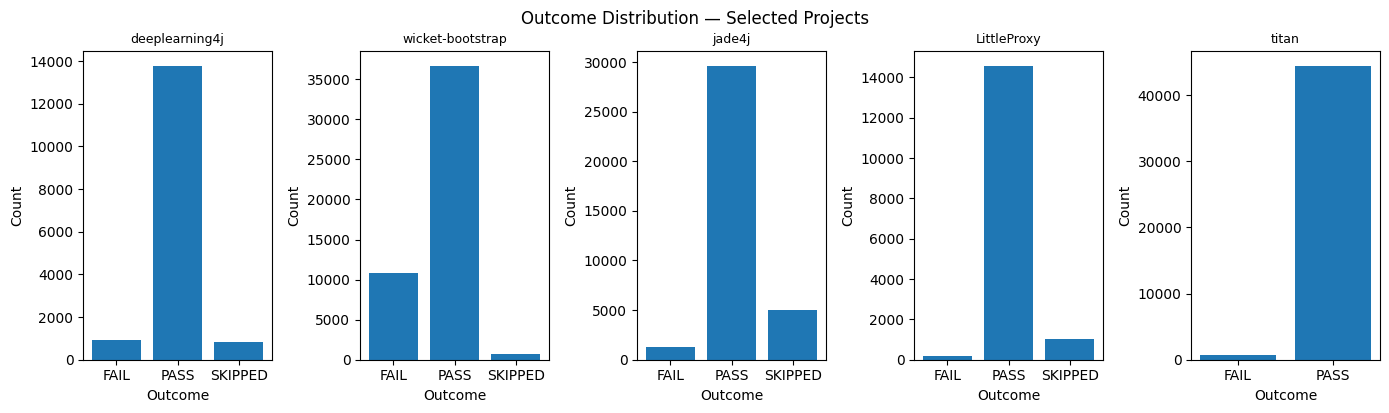

,repo,outcome,cnt
0,adamfisk@LittleProxy,FAIL,187
1,adamfisk@LittleProxy,PASS,14563
2,adamfisk@LittleProxy,SKIPPED,1022
3,deeplearning4j@deeplearning4j,FAIL,932
4,deeplearning4j@deeplearning4j,PASS,13769
5,deeplearning4j@deeplearning4j,SKIPPED,808
6,l0rdn1kk0n@wicket-bootstrap,FAIL,10860
7,l0rdn1kk0n@wicket-bootstrap,PASS,36648
8,l0rdn1kk0n@wicket-bootstrap,SKIPPED,720
9,neuland@jade4j,FAIL,1323


In [5]:
placeholders = ",".join(["?"] * len(SELECTED_PROJECTS))
outcome_dist = pd.read_sql(
    f"""
    SELECT repo, outcome, COUNT(*) AS cnt
    FROM test_runs
    WHERE repo IN ({placeholders})
    GROUP BY repo, outcome
    ORDER BY repo, outcome
    """,
    con,
    params=SELECTED_PROJECTS,
)

fig, axes = plt.subplots(1, len(SELECTED_PROJECTS), figsize=(14, 4))
for ax, project in zip(axes, SELECTED_PROJECTS):
    data = outcome_dist[outcome_dist["repo"] == project]
    ax.bar(data["outcome"], data["cnt"])
    ax.set_title(project.split("@")[1], fontsize=9)
    ax.set_xlabel("Outcome")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.suptitle("Outcome Distribution — Selected Projects", y=1.02)
plt.show()

display(outcome_dist)

## 5. Top 10 Most Frequently Failing Tests (per selected project)

In [6]:
for project in SELECTED_PROJECTS:
    top10 = pd.read_sql(
        """
        SELECT test_id, COUNT(*) AS fail_count
        FROM test_runs
        WHERE repo = ? AND outcome = 'FAIL'
        GROUP BY test_id
        ORDER BY fail_count DESC
        LIMIT 10
        """,
        con,
        params=[project],
    )
    print(f"\n=== {project} ===")
    display(top10)


=== deeplearning4j@deeplearning4j ===


,test_id,fail_count
0,org.deeplearning4j.nn.graph.TestCompGraphMulti,84
1,org.deeplearning4j.rbm.ConvRBMTest,82
2,org.deeplearning4j.rbm.RBMTest,72
3,org.deeplearning4j.sda.SdaTest,60
4,org.deeplearning4j.eval.EvalTest,56
5,org.deeplearning4j.convolution.ConvolutionTest,52
6,org.deeplearning4j.autoencoder.DeepAutoEncoder...,44
7,org.deeplearning4j.datasets.DataSetTest,35
8,org.deeplearning4j.dbn.DBNTest,29
9,org.deeplearning4j.models.layers.ConvolutionDo...,23



=== l0rdn1kk0n@wicket-bootstrap ===


,test_id,fail_count
0,de.agilecoders.wicket.core.markup.html.bootstr...,375
1,de.agilecoders.wicket.core.markup.html.bootstr...,375
2,de.agilecoders.wicket.core.markup.html.themes....,375
3,de.agilecoders.wicket.core.markup.html.bootstr...,374
4,de.agilecoders.wicket.core.markup.html.bootstr...,374
5,de.agilecoders.wicket.core.markup.html.bootstr...,374
6,de.agilecoders.wicket.core.markup.html.bootstr...,374
7,de.agilecoders.wicket.core.markup.html.bootstr...,374
8,de.agilecoders.wicket.core.markup.html.bootstr...,374
9,de.agilecoders.wicket.core.markup.html.bootstr...,374



=== neuland@jade4j ===


,test_id,fail_count
0,de.neuland.jade4j.exceptions.JadeExceptionTest,68
1,de.neuland.jade4j.compiler.OriginalJade2015051...,65
2,de.neuland.jade4j.compiler.CompilerTest,62
3,de.neuland.jade4j.compiler.OriginalJadeTest,61
4,de.neuland.jade4j.lexer.token.OutdentTest,57
5,de.neuland.jade4j.parser.LargeBodyTextWithoutP...,57
6,de.neuland.jade4j.parser.IncludeParserTest,57
7,de.neuland.jade4j.lexer.token.TextTest,57
8,de.neuland.jade4j.lexer.token.AttributeTest,57
9,de.neuland.jade4j.lexer.token.CssClassTest,57



=== adamfisk@LittleProxy ===


,test_id,fail_count
0,org.littleshoot.proxy.EncryptedUDTChainedProxy...,24
1,org.littleshoot.proxy.UnencryptedUDTChainedPro...,20
2,org.littleshoot.proxy.SimpleProxyTest,20
3,org.littleshoot.proxy.EncryptedTCPChainedProxy...,17
4,org.littleshoot.proxy.UsernamePasswordAuthenti...,16
5,org.littleshoot.proxy.ChainedProxyWithFallback...,12
6,org.littleshoot.proxy.UnencryptedTCPChainedPro...,12
7,org.littleshoot.proxy.EndToEndStoppingTest,11
8,org.littleshoot.proxy.BadClientAuthenticationT...,10
9,org.littleshoot.proxy.MitmProxyTest,10



=== thinkaurelius@titan ===


,test_id,fail_count
0,com.thinkaurelius.titan.diskstorage.cassandra....,65
1,com.thinkaurelius.titan.diskstorage.cassandra....,64
2,com.thinkaurelius.titan.blueprints.BerkeleyJEB...,30
3,com.thinkaurelius.titan.tinkerpop.rexster.pers...,24
4,com.thinkaurelius.titan.graphdb.persistit.Pers...,24
5,com.thinkaurelius.titan.diskstorage.persistit....,23
6,com.thinkaurelius.titan.blueprints.persistit.P...,23
7,com.thinkaurelius.titan.diskstorage.persistit....,23
8,com.thinkaurelius.titan.diskstorage.persistit....,22
9,com.thinkaurelius.titan.blueprints.InternalCas...,22


## 6. Duration Distribution (selected projects)


deeplearning4j@deeplearning4j duration_ms (n=13,804):
  min     : 1.0 ms
  median  : 737.0 ms
  p95     : 89,371.3 ms
  max     : 2,586,712.0 ms
  mean    : 35,645.5 ms


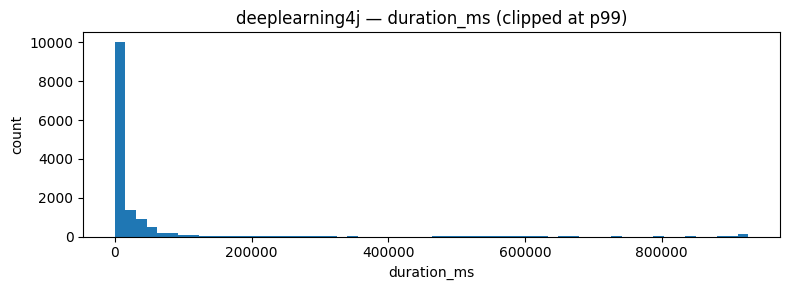


l0rdn1kk0n@wicket-bootstrap duration_ms (n=47,678):
  min     : 1.0 ms
  median  : 53.0 ms
  p95     : 695.0 ms
  max     : 12,389.0 ms
  mean    : 164.1 ms


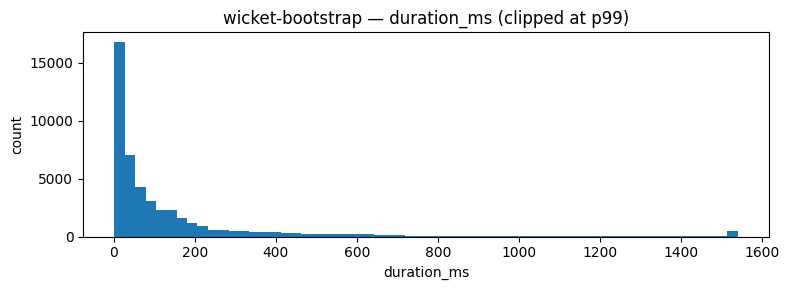


neuland@jade4j duration_ms (n=24,512):
  min     : 1.0 ms
  median  : 4.0 ms
  p95     : 639.0 ms
  max     : 572,163.0 ms
  mean    : 167.2 ms


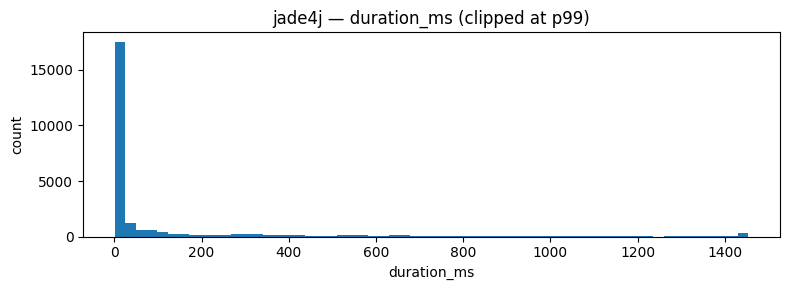


adamfisk@LittleProxy duration_ms (n=14,967):
  min     : 1.0 ms
  median  : 2,214.0 ms
  p95     : 30,252.4 ms
  max     : 204,105.0 ms
  mean    : 5,129.1 ms


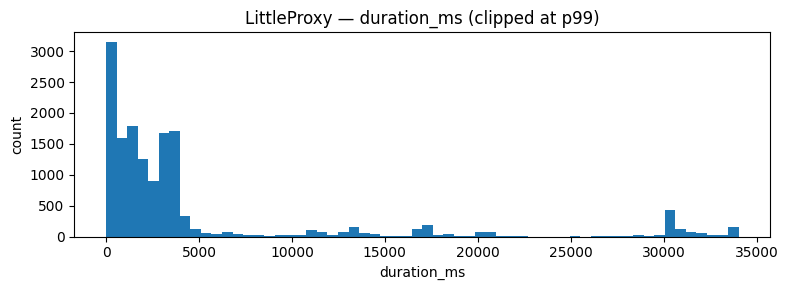


thinkaurelius@titan duration_ms (n=43,249):


  min     : 1.0 ms
  median  : 14,544.0 ms
  p95     : 211,055.6 ms
  max     : 941,912.0 ms
  mean    : 46,157.3 ms


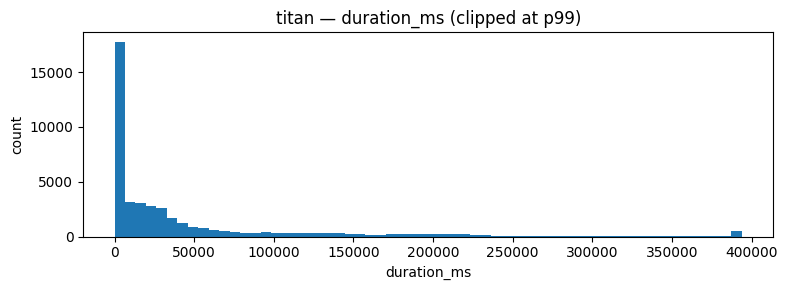

In [7]:
for project in SELECTED_PROJECTS:
    dur = pd.read_sql(
        """
        SELECT duration_ms
        FROM test_runs
        WHERE repo = ? AND duration_ms IS NOT NULL AND duration_ms > 0
        """,
        con,
        params=[project],
    )["duration_ms"]

    stats = {
        "min": dur.min(),
        "median": dur.median(),
        "p95": dur.quantile(0.95),
        "max": dur.max(),
        "mean": dur.mean(),
    }
    print(f"\n{project} duration_ms (n={len(dur):,}):")
    for k, v in stats.items():
        print(f"  {k:8s}: {v:,.1f} ms")

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(dur.clip(upper=dur.quantile(0.99)), bins=60, edgecolor="none")
    ax.set_title(f"{project.split('@')[1]} — duration_ms (clipped at p99)")
    ax.set_xlabel("duration_ms")
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()

## 7. file_changes Rows per Selected Project

In [8]:
placeholders = ",".join(["?"] * len(SELECTED_PROJECTS))
fc_counts = pd.read_sql(
    f"""
    SELECT repo,
           COUNT(*) AS file_change_rows,
           COUNT(DISTINCT commit_sha) AS distinct_commits
    FROM file_changes
    WHERE repo IN ({placeholders})
    GROUP BY repo
    """,
    con,
    params=SELECTED_PROJECTS,
)
display(fc_counts)

,repo,file_change_rows,distinct_commits
0,thinkaurelius@titan,6413,679
1,neuland@jade4j,3135,374
2,deeplearning4j@deeplearning4j,61402,2607
3,adamfisk@LittleProxy,2614,611
4,l0rdn1kk0n@wicket-bootstrap,10248,1294


## 8. Cross-Check vs Offenders CSV

For each selected project, verify that jobs flagged in `<project>-offenders.csv`
have matching `outcome=FAIL` rows in `test_runs`.

In [9]:
import csv

for project in SELECTED_PROJECTS:
    short_name = project.split("@", 1)[1] if "@" in project else project
    offenders_path = RTP_PATH / project / f"{project}-offenders.csv"

    if not offenders_path.exists():
        print(f"[{short_name}] offenders.csv not found — skipping")
        continue

    offender_jobs: list[str] = []
    with offenders_path.open("r", newline="", encoding="utf-8-sig") as fh:
        reader = csv.DictReader(fh)
        for row in reader:
            # Column name in RTPTorrent offenders CSVs is tr_job_id (int or string)
            jid = row.get("tr_job_id", "").strip()
            if jid:
                offender_jobs.append(str(int(jid)))  # normalise: strip leading zeros

    if not offender_jobs:
        print(f"[{short_name}] no offender job IDs parsed")
        continue

    placeholders_jobs = ",".join(["?"] * len(offender_jobs))
    matched = pd.read_sql(
        f"""
        SELECT COUNT(*) AS matched_fail_rows
        FROM test_runs
        WHERE repo = ?
          AND outcome = 'FAIL'
          AND CAST(job_id AS TEXT) IN ({placeholders_jobs})
        """,
        con,
        params=[project] + offender_jobs,
    ).iloc[0, 0]

    pct = matched / len(offender_jobs) * 100 if offender_jobs else 0.0
    print(f"[{short_name}]  offender jobs: {len(offender_jobs)} | matched FAIL rows: {matched} | rate: {pct:.1f}%")
    if pct < 50:
        print(f"  WARNING: low cross-check match rate for {short_name}")


[deeplearning4j]  offender jobs: 441 | matched FAIL rows: 708 | rate: 160.5%
[wicket-bootstrap]  offender jobs: 201 | matched FAIL rows: 5292 | rate: 2632.8%
[jade4j]  offender jobs: 24 | matched FAIL rows: 339 | rate: 1412.5%
[LittleProxy]  offender jobs: 32 | matched FAIL rows: 90 | rate: 281.2%
[titan]  offender jobs: 100 | matched FAIL rows: 204 | rate: 204.0%


In [10]:
## 8b. job_sequence Verification

js_nulls = pd.read_sql("SELECT COUNT(*) as n FROM test_runs WHERE job_sequence IS NULL", con).iloc[0, 0]
placeholders_js = ",".join(["?"] * len(SELECTED_PROJECTS))
js_sample = pd.read_sql(
    f"""
    SELECT repo,
           MIN(job_sequence) AS min_seq,
           MAX(job_sequence) AS max_seq,
           COUNT(DISTINCT job_sequence) AS distinct_seqs,
           COUNT(DISTINCT job_id) AS distinct_jobs
    FROM test_runs
    WHERE repo IN ({placeholders_js})
    GROUP BY repo
    ORDER BY repo
    """,
    con,
    params=SELECTED_PROJECTS,
)

print(f"NULL job_sequence rows (all repos): {js_nulls}")
assert js_nulls == 0, f"FAIL: job_sequence has {js_nulls} NULL values"
display(js_sample)
mismatch = js_sample[js_sample["distinct_seqs"] != js_sample["distinct_jobs"]]
assert len(mismatch) == 0, f"FAIL: DENSE_RANK mismatch: {mismatch}"
print("PASS: job_sequence populated and contiguous for all selected projects")

NULL job_sequence rows (all repos): 0


,repo,min_seq,max_seq,distinct_seqs,distinct_jobs
0,adamfisk@LittleProxy,1,581,581,581
1,deeplearning4j@deeplearning4j,1,1038,1038,1038
2,l0rdn1kk0n@wicket-bootstrap,1,1110,1110,1110
3,neuland@jade4j,1,932,932,932
4,thinkaurelius@titan,1,1075,1075,1075


PASS: job_sequence populated and contiguous for all selected projects


## 9. Summary Assertions

In [11]:
selected_quality = quality[quality["repo"].isin(SELECTED_PROJECTS)].copy()

print("=== Sprint 1 Acceptance Checks ===")
print(f"Total test_runs: {total_runs:,} (need >= 10,000)")

for _, row in selected_quality.iterrows():
    repo = row["repo"]
    fr = row["failure_rate"]
    nr = row["null_sha_rate"]
    fail_ok = fr >= 0.01  # ADR 2026-05-10: threshold lowered from 2% to 1%
    null_warn = nr > 0.40
    status = "OK" if fail_ok else "FAIL (failure_rate < 1%)"
    warn = " | WARNING: null_sha > 40%" if null_warn else ""
    print(f"  {repo}: failure_rate={fr:.2%}, null_sha={nr:.1%} [{status}{warn}]")

all_ok = all(row["failure_rate"] >= 0.01 for _, row in selected_quality.iterrows())
assert all_ok, "FAIL: one or more selected projects have failure_rate < 1%"
print("\nValidation complete.")
con.close()

=== Sprint 1 Acceptance Checks ===
Total test_runs: 160,454 (need >= 10,000)
  adamfisk@LittleProxy: failure_rate=1.19%, null_sha=30.4% [OK]
  deeplearning4j@deeplearning4j: failure_rate=6.01%, null_sha=5.7% [OK]
  l0rdn1kk0n@wicket-bootstrap: failure_rate=22.52%, null_sha=19.3% [OK]
  neuland@jade4j: failure_rate=3.69%, null_sha=0.1% [OK]
  thinkaurelius@titan: failure_rate=1.46%, null_sha=12.9% [OK]

Validation complete.
